# Enhancing Medical Image Representation using DRL and Transfer Learning

## Objective
This project aims to improve medical image representation using:
- Transfer Learning (CNN pretrained models)
- Deep Reinforcement Learning (DRL)
- Domain Adaptation techniques

We evaluate whether these techniques improve classification performance on medical images such as chest X-rays.

## Dataset Description

We use a chest X-ray dataset containing two classes:
- NORMAL
- PNEUMONIA

The dataset is split into:
- Train
- Validation
- Test

# Imports + path

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

import torch
import torch.nn as nn
import pandas as pd
import json

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from baseline_model import get_model
from dataset import get_dataloaders
from preprocessing import get_baseline_transforms
from evaluate import evaluate

# device + dataloaders

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader, val_loader, test_loader = get_dataloaders(
    "../data_resplit/train",
    "../data_resplit/val",
    "../data_resplit/test",
    train_transform=get_baseline_transforms(),
    eval_transform=get_baseline_transforms(),
    batch_size=32
)

print("Device:", device)
print("Train:", len(train_loader.dataset))
print("Validation:", len(val_loader.dataset))
print("Test:", len(test_loader.dataset))
print("Classes:", test_loader.dataset.class_to_idx)

Device: cpu
Train: 5970
Validation: 1278
Test: 1282
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


# helper function to get metrics

In [3]:
def get_metrics(model, dataloader, device):
    model.eval()

    predictions = []
    labels_list = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            predictions.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_list, predictions)

    return acc, predictions, labels_list

# evaluate baseline CNN

In [4]:
baseline_model = get_model()

baseline_model.load_state_dict(
    torch.load("../models/best_baseline.pth", map_location=device)
)

baseline_model = baseline_model.to(device)

baseline_acc, baseline_preds, baseline_labels = get_metrics(
    baseline_model,
    test_loader,
    device
)

print("BASELINE CNN")
print("Accuracy:", baseline_acc)
print(classification_report(baseline_labels, baseline_preds))
print(confusion_matrix(baseline_labels, baseline_preds))

BASELINE CNN
Accuracy: 0.9797191887675507
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       641
           1       0.99      0.97      0.98       641

    accuracy                           0.98      1282
   macro avg       0.98      0.98      0.98      1282
weighted avg       0.98      0.98      0.98      1282

[[632   9]
 [ 17 624]]


# show DRL learned policy

In [5]:
with open("../results/rl_policy.json", "r") as f:
    rl_policy = json.load(f)

print("DRL POLICY")
print(rl_policy)

best_action = int(rl_policy["best_action"])
action_name = rl_policy["actions"][str(best_action)]

print("Selected action:", best_action)
print("Selected augmentation:", action_name)
print("Proxy validation accuracy:", rl_policy["best_accuracy"])

DRL POLICY
{'best_action': 1, 'best_accuracy': 0.975, 'actions': {'0': 'rotation', '1': 'horizontal_flip', '2': 'random_crop', '3': 'contrast_adjustment'}}
Selected action: 1
Selected augmentation: horizontal_flip
Proxy validation accuracy: 0.975


# evaluate DRL-Augmented CNN

In [6]:
drl_model = get_model()

drl_model.load_state_dict(
    torch.load("../models/best_drl.pth", map_location=device)
)

drl_model = drl_model.to(device)

drl_acc, drl_preds, drl_labels = get_metrics(
    drl_model,
    test_loader,
    device
)

print("DRL-AUGMENTED CNN")
print("Accuracy:", drl_acc)
print(classification_report(drl_labels, drl_preds))
print(confusion_matrix(drl_labels, drl_preds))

DRL-AUGMENTED CNN
Accuracy: 0.9750390015600624
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       641
           1       0.98      0.98      0.98       641

    accuracy                           0.98      1282
   macro avg       0.98      0.98      0.98      1282
weighted avg       0.98      0.98      0.98      1282

[[625  16]
 [ 16 625]]


# evaluate CORAL Domain Adaptation

In [7]:
from feature_extraction import FeatureExtractor

feature_extractor = FeatureExtractor().to(device)
classifier = nn.Linear(2048, 2).to(device)

checkpoint = torch.load("../models/best_coral.pth", map_location=device)

feature_extractor.load_state_dict(checkpoint["feature_extractor"])
classifier.load_state_dict(checkpoint["classifier"])

feature_extractor.eval()
classifier.eval()

coral_predictions = []
coral_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        features = feature_extractor(images)
        outputs = classifier(features)

        preds = outputs.argmax(dim=1)

        coral_predictions.extend(preds.cpu().numpy())
        coral_labels.extend(labels.cpu().numpy())

coral_acc = accuracy_score(coral_labels, coral_predictions)

print("DOMAIN ADAPTATION / CORAL")
print("Accuracy:", coral_acc)
print(classification_report(coral_labels, coral_predictions))
print(confusion_matrix(coral_labels, coral_predictions))

C:\Users\hafsa\Desktop\AI-PROJET\DRL PROJECT\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\hafsa\Desktop\AI-PROJET\DRL PROJECT\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DOMAIN ADAPTATION / CORAL
Accuracy: 0.9820592823712948
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       641
           1       0.99      0.97      0.98       641

    accuracy                           0.98      1282
   macro avg       0.98      0.98      0.98      1282
weighted avg       0.98      0.98      0.98      1282

[[636   5]
 [ 18 623]]


# final comparison table

In [8]:
results = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "DRL + CNN",
        "DRL + CNN + CORAL"
    ],
    "Description": [
        "ResNet50 transfer learning without DRL",
        f"CNN trained with PPO-selected medical augmentation: {action_name}",
        f"DRL-selected augmentation + CORAL feature alignment"
    ],
    "Accuracy": [
        baseline_acc,
        drl_acc,
        drl_coral_acc
    ]
})

results

,Model,Description,Accuracy
0,Baseline CNN,ResNet50 transfer learning without DRL,0.979719
1,DRL-Augmented CNN,CNN trained with DRL-selected augmentation: ho...,0.975039
2,CORAL Domain Adaptation,Feature alignment using CORAL loss,0.982059


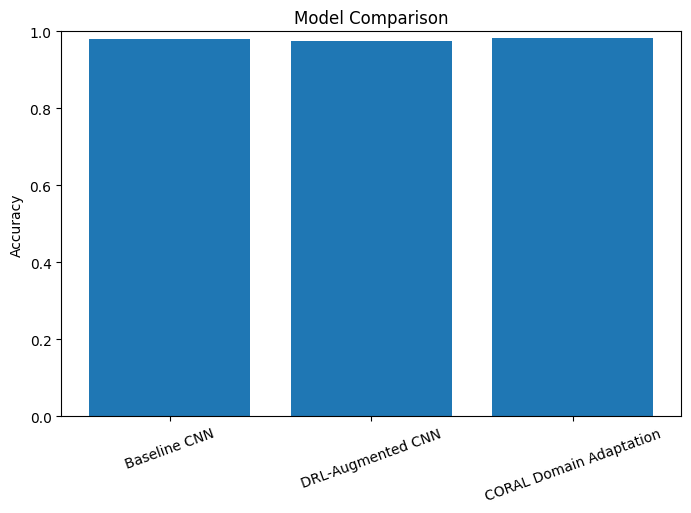

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Accuracy"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()